In [246]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels as sm
import statsmodels.api as sma

ImportError: cannot import name '_lazywhere' from 'scipy._lib._util' (C:\Users\k\anaconda3\Lib\site-packages\scipy\_lib\_util.py)

# Loading Dataset

In [187]:
df = pd.read_excel('CBN_Data.xlsx')

In [188]:
df.head()

,Year,Total_Import,Total_Export,Total_Trade,Net_Trade,Inflation,Growth_Rate,GDP,CEX,REX
0,1985,7062.6,11720.8,18783.4,4658.2,1.030928,8.524826,17170.081087,13.0411,7.5764
1,1986,5983.6,8920.6,14904.2,2937.0,13.673469,1.899665,17180.545440,16.2237,7.6969
2,1987,17861.7,30360.6,48222.3,12498.9,9.694794,0.170244,17730.344450,22.0187,15.6462
3,1988,21445.7,31192.8,52638.5,9747.1,61.211129,6.233269,19030.692431,27.7495,19.4094
4,1989,30860.2,57971.2,88831.4,27111.0,44.670051,6.656061,19395.963982,41.0283,25.9942


In [189]:
# Copying the Data

In [190]:
Data = df.copy()

In [191]:
# df.set_index('Year', inplace = True), # Removing the index, and make Year the new index

In [192]:
df.info(), # data info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Year          40 non-null     int64  
 1   Total_Import  40 non-null     float64
 2   Total_Export  40 non-null     float64
 3   Total_Trade   40 non-null     float64
 4   Net_Trade     40 non-null     float64
 5   Inflation     39 non-null     float64
 6   Growth_Rate   40 non-null     float64
 7   GDP           40 non-null     float64
 8   CEX           39 non-null     float64
 9   REX           39 non-null     float64
dtypes: float64(9), int64(1)
memory usage: 3.3 KB


(None,)

In [193]:
df.describe()

,Year,Total_Import,Total_Export,Total_Trade,Net_Trade,Inflation,Growth_Rate,GDP,CEX,REX
count,40.000000,4.000000e+01,4.000000e+01,4.000000e+01,4.000000e+01,39.000000,40.000000,40.000000,39.000000,39.000000
mean,2004.500000,7.876343e+06,9.390942e+06,1.726728e+07,1.514599e+06,19.525691,4.463206,43141.407549,3512.219197,2532.797095
std,11.690452,1.232299e+07,1.398496e+07,2.615219e+07,3.306476e+06,17.775666,3.773269,22039.744097,4578.954317,3393.150243
min,1985.000000,5.983600e+03,8.920600e+03,1.490420e+04,-7.905599e+06,0.223606,-1.920000,17170.081087,13.041100,7.576400
25%,1994.750000,4.633773e+05,6.185850e+05,1.288056e+06,2.345797e+04,10.106667,1.892836,22649.719787,219.998500,125.960550
50%,2004.500000,2.440546e+06,5.924658e+06,8.318609e+06,3.612001e+05,12.200000,3.716017,37604.193723,1504.200000,1110.800000
75%,2014.250000,1.060540e+07,1.321856e+07,2.472433e+07,3.665717e+06,19.971897,6.796595,68146.202006,4850.463194,3557.979498
max,2024.000000,6.428908e+07,7.785403e+07,1.421431e+08,1.356495e+07,76.758866,14.604381,80606.533346,19808.437541,14287.564541


In [194]:
# data shape (Rows, Columns)

In [195]:
df.shape

(40, 10)

In [196]:
# Checking the null

In [197]:
df.isnull().sum()

Year            0
Total_Import    0
Total_Export    0
Total_Trade     0
Net_Trade       0
Inflation       1
Growth_Rate     0
GDP             0
CEX             1
REX             1
dtype: int64

In [198]:
# Filling Null Values with mean

In [199]:
df.fillna(df.mean(numeric_only = True), inplace = True)

In [200]:
df

,Year,Total_Import,Total_Export,Total_Trade,Net_Trade,Inflation,Growth_Rate,GDP,CEX,REX
0,1985,7.062600e+03,1.172080e+04,1.878340e+04,4.658200e+03,1.030928,8.524826,17170.081087,13.041100,7.576400
1,1986,5.983600e+03,8.920600e+03,1.490420e+04,2.937000e+03,13.673469,1.899665,17180.545440,16.223700,7.696900
2,1987,1.786170e+04,3.036060e+04,4.822230e+04,1.249890e+04,9.694794,0.170244,17730.344450,22.018700,15.646200
3,1988,2.144570e+04,3.119280e+04,5.263850e+04,9.747100e+03,61.211129,6.233269,19030.692431,27.749500,19.409400
4,1989,3.086020e+04,5.797120e+04,8.883140e+04,2.711100e+04,44.670051,6.656061,19395.963982,41.028300,25.994200
5,1990,4.571790e+04,1.098861e+05,1.556040e+05,6.416820e+04,3.614035,11.627609,21680.204536,60.268200,36.219600
6,1991,8.948820e+04,1.215354e+05,2.110236e+05,3.204720e+04,22.959702,-0.552030,21757.896113,66.584400,38.243500
7,1992,1.431512e+05,2.056117e+05,3.487629e+05,6.246050e+04,48.801983,2.193493,22765.546263,92.797400,53.034100
8,1993,1.656294e+05,2.187701e+05,3.843995e+05,5.314070e+04,61.262262,1.568807,22302.240357,191.228900,136.727100
9,1994,1.627888e+05,2.060592e+05,3.688480e+05,4.327040e+04,76.758866,0.256575,21897.471536,160.893200,89.974900


# Checking for Outliers using boxplot

<Axes: xlabel='GDP'>

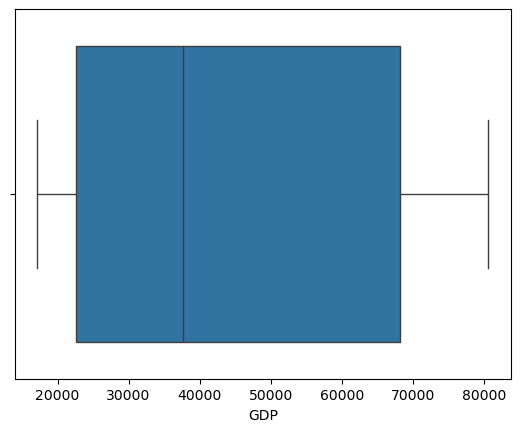

In [201]:
sns.boxplot(x = df['GDP'])

<Axes: xlabel='Growth_Rate'>

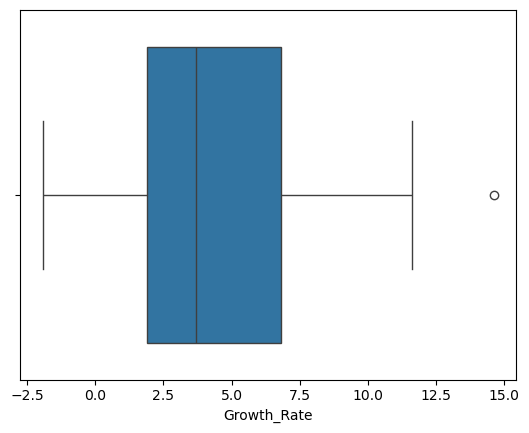

In [202]:
sns.boxplot(x = df['Growth_Rate']) # one outlier

In [203]:
df[df['Growth_Rate'] > 13]

,Year,Total_Import,Total_Export,Total_Trade,Net_Trade,Inflation,Growth_Rate,GDP,CEX,REX
17,2002,1512695.33,1744177.677,3256873.007,231482.347,12.2,14.604381,31064.272133,1018.1781,696.8


In [204]:
df[df['Growth_Rate'] > 13].index

Index([17], dtype='int64')

In [205]:
#df.drop([17], inplace = True)

<Axes: xlabel='REX'>

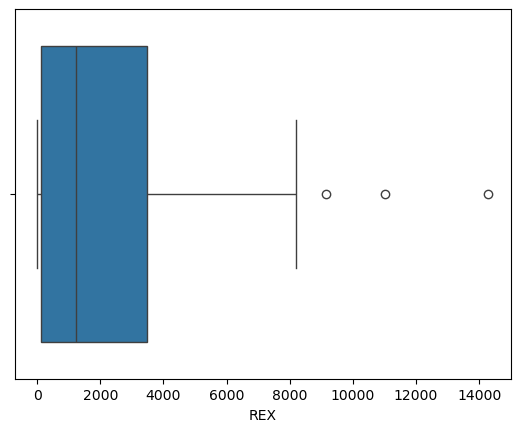

In [206]:
sns.boxplot(x = df['REX']) # three outliers

In [207]:
df['REX'] > 8000

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35     True
36     True
37     True
38     True
39    False
Name: REX, dtype: bool

In [208]:
df[df['REX'] > 8000]

,Year,Total_Import,Total_Export,Total_Trade,Net_Trade,Inflation,Growth_Rate,GDP,CEX,REX
35,2020,2.051919e+07,1.261359e+07,3.313278e+07,-7.905599e+06,15.800000,-1.920000,70800.543492,10232.330339,8189.381339
36,2021,2.295484e+07,1.920417e+07,4.215901e+07,-3.750665e+06,15.625489,0.508191,73382.771385,12164.146255,9145.154255
37,2022,2.711511e+07,2.725157e+07,5.436668e+07,1.364638e+05,21.343795,3.102199,74752.416581,14946.249497,11002.306497
38,2023,3.264267e+07,3.624779e+07,6.889045e+07,3.605122e+06,28.920000,2.740469,77936.100052,19808.437541,14287.564541


# Exploratory Data Analysis (EDA)

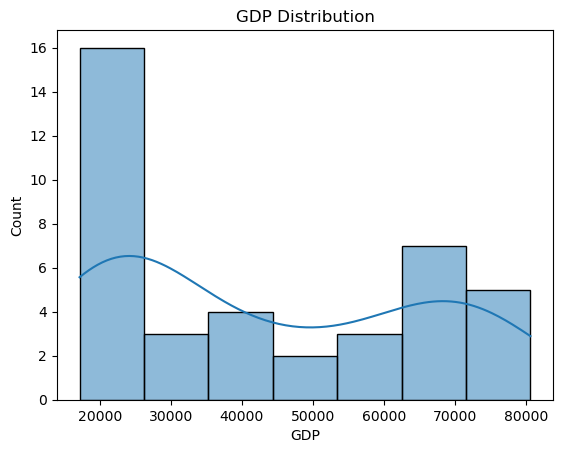

In [209]:
sns.histplot(df['GDP'], kde=True)
plt.title('GDP Distribution')
plt.show()

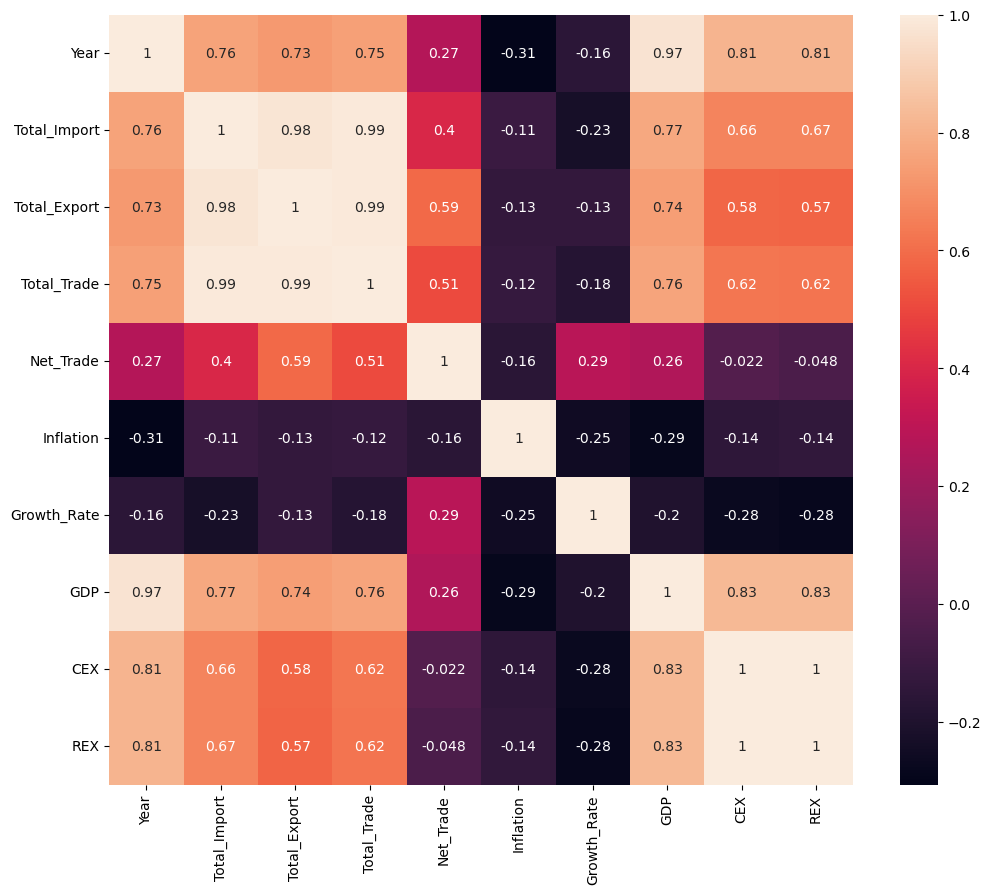

In [210]:
plt.figure(figsize =(12, 10))
relationship = df.corr()
sns.heatmap(relationship, annot = True)
plt.show()


# Selecting Features and Target

In [211]:
y = df['GDP']
X = df.drop('GDP', axis = 1)

In [212]:
# Checking for X

In [213]:
X

,Year,Total_Import,Total_Export,Total_Trade,Net_Trade,Inflation,Growth_Rate,CEX,REX
0,1985,7.062600e+03,1.172080e+04,1.878340e+04,4.658200e+03,1.030928,8.524826,13.041100,7.576400
1,1986,5.983600e+03,8.920600e+03,1.490420e+04,2.937000e+03,13.673469,1.899665,16.223700,7.696900
2,1987,1.786170e+04,3.036060e+04,4.822230e+04,1.249890e+04,9.694794,0.170244,22.018700,15.646200
3,1988,2.144570e+04,3.119280e+04,5.263850e+04,9.747100e+03,61.211129,6.233269,27.749500,19.409400
4,1989,3.086020e+04,5.797120e+04,8.883140e+04,2.711100e+04,44.670051,6.656061,41.028300,25.994200
5,1990,4.571790e+04,1.098861e+05,1.556040e+05,6.416820e+04,3.614035,11.627609,60.268200,36.219600
6,1991,8.948820e+04,1.215354e+05,2.110236e+05,3.204720e+04,22.959702,-0.552030,66.584400,38.243500
7,1992,1.431512e+05,2.056117e+05,3.487629e+05,6.246050e+04,48.801983,2.193493,92.797400,53.034100
8,1993,1.656294e+05,2.187701e+05,3.843995e+05,5.314070e+04,61.262262,1.568807,191.228900,136.727100
9,1994,1.627888e+05,2.060592e+05,3.688480e+05,4.327040e+04,76.758866,0.256575,160.893200,89.974900


In [214]:
# Checking for y

In [215]:
y.head()

0    17170.081087
1    17180.545440
2    17730.344450
3    19030.692431
4    19395.963982
Name: GDP, dtype: float64

# Test_Train_Split

In [216]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [217]:
print('feature_shape:', X.shape)
print('target_shape:',y.shape)

feature_shape: (40, 9)
target_shape: (40,)


In [218]:
print('X_train:', X_train.shape)
print('X_test:', X_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

X_train: (32, 9)
X_test: (8, 9)
y_train: (32,)
y_test: (8,)


In [219]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Building (Linear Regression)

In [220]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

In [221]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Linear Regression Result when scaled

In [222]:
print('mae:', mae)
print('mse:', mse)
print('rmse:', rmse)
print('r2:', r2)

mae: 4790.842461207556
mse: 25789491.423655592
rmse: 5078.335497351036
r2: 0.9324777217943987


# Linear Regression Result without scaled

In [223]:
mae: 4920.40205506761
mse: 28380984.651221745
rmse: 5327.380655746475
r2: 0.9256926509372375

# Model Building Using Random Forest

In [224]:
rf = RandomForestRegressor(n_estimators = 100, random_state = 42)
rf.fit(X_train_scaled, y_train)
y_pred2 = rf.predict(X_test_scaled)

In [225]:
mae = mean_absolute_error(y_test, y_pred2)
mse = mean_squared_error(y_test, y_pred2)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred2)

In [226]:
# When scaled

In [227]:
print('mae:', mae) 
print('mse:', mse)
print('rmse:', rmse)
print('r2:', r2)

mae: 2340.8508390376956
mse: 10952341.589750167
rmse: 3309.4322156149638
r2: 0.9713244808252577


In [228]:
# Without scale

In [229]:
mae: 2212.8868433136013
mse: 9400810.067359343
rmse: 3066.074047925024
r2: 0.9753867146001951

# Feature Importance Using RandomForest

In [230]:
feature_importance = pd.DataFrame({"Feature": X.columns, 'Importance': rf.feature_importances_})
feature_importance.sort_values(by = 'Importance', ascending = False)

,Feature,Importance
0,Year,0.271453
1,Total_Import,0.179134
7,CEX,0.169926
8,REX,0.132766
3,Total_Trade,0.122273
2,Total_Export,0.084893
6,Growth_Rate,0.029184
4,Net_Trade,0.007853
5,Inflation,0.002518


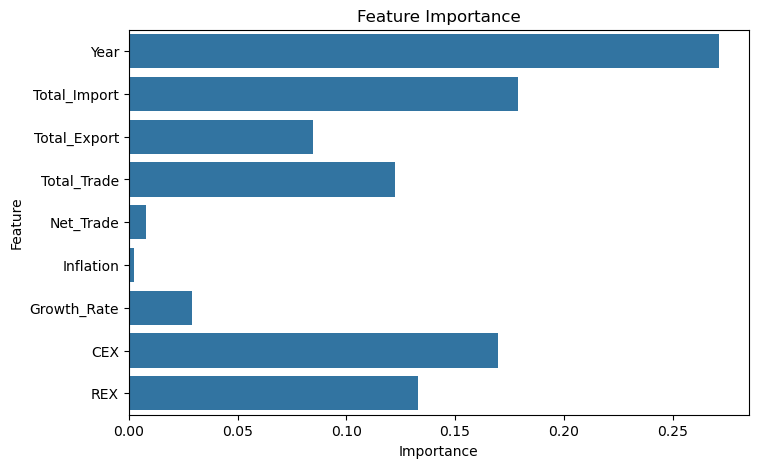

In [231]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature')

plt.title('Feature Importance')
plt.show()

# Retrain Final Model Using RandomForestregressor

In [232]:
new_features = ['Year', 'Total_Import','CEX', 'REX', 'Total_Trade']
X_new = df[new_features]
y_new = df['GDP']

In [233]:
X_new_train, X_new_test, y_new_train, y_new_test = train_test_split(X_new, y_new, test_size = 0.2, random_state = 42)

In [234]:
print('feature_shape;', X_new.shape)
print('target_shape:',y_new.shape)

feature_shape; (40, 5)
target_shape: (40,)


In [235]:
print('X_new_train:', X_new_train.shape)
print('X_new_test:', X_new_test.shape)
print('y_new_train:', y_new_train.shape)
print('y_new_test:', y_new_test.shape)

X_new_train: (32, 5)
X_new_test: (8, 5)
y_new_train: (32,)
y_new_test: (8,)


In [236]:
rf_new = RandomForestRegressor(n_estimators = 100, random_state = 42)
rf_new.fit(X_new_train, y_new_train)
y_pred_ = rf_new.predict(X_new_test)

In [237]:
mae_new = mean_absolute_error(y_new_test, y_pred_)
mse_new = mean_squared_error(y_new_test, y_pred_)
rmse_new = np.sqrt(mse)
r2_new = r2_score(y_new_test, y_pred_)

In [238]:
print('mae_new:', mae_new) 
print('mse_new:', mse_new)
print('rmse_new:', rmse_new)
print('r2_new:', r2_new)

mae_new: 1745.7592043648265
mse_new: 5458744.206185252
rmse_new: 3309.4322156149638
r2_new: 0.9857078668637426


In [239]:
import joblib
joblib.dump(rf_new, "CBN_GDP.pkl")

['CBN_GDP.pkl']

In [240]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

# Loading the Model

In [241]:
Model = joblib.load("CBN_GDP.pkl")

print(Model)

RandomForestRegressor(random_state=42)


In [242]:
Data = pd.DataFrame({
    'Year':[2025],
    'Total_Import':[50000],
    'CEX':[500000],
    'REX':[300000],
    'Total_Trade':[95000]
   
})

prediction = Model.predict(Data)

print("Predicted GDP:", prediction[0])

Predicted GDP: 56069.62844852111
